# Part 1 - Vectorisation, Comparison, and Machine Learning

## 1. Aim

This notebook performs vectorisation, method comparison, clustering, and plotting for the cleaned datasets.

The goal is to compare different feature representations across text, image, and audio data, and evaluate how useful they are for:
- analysis
- clustering
- later parameter mapping into 3D generation

This notebook includes:
- vectorisation
- comparison between methods
- KMeans clustering
- PCA-based plotting

## 2. Methods Overview

### Text
- TF-IDF
- sentence embeddings

### Image
- handcrafted visual features

### Audio
- basic spectral features
- MFCC

### Machine Learning
- KMeans clustering

### Visualisation
- Matplotlib
- Seaborn
- PCA scatter plots

## 3. Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sentence_transformers import SentenceTransformer
import librosa

c:\Users\Greeny\anaconda3\envs\surface\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().resolve().parent.parent

CLEANED_DIR = BASE_DIR / "data" / "cleaned"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

TEXT_CLEAN_DIR = CLEANED_DIR / "text"
IMAGE_CLEAN_DIR = CLEANED_DIR / "images"
AUDIO_CLEAN_DIR = CLEANED_DIR / "audio"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)

BASE_DIR: D:\Work\Workspace\Projects\Python\data-driven-surface


## 4. Load Cleaned Datasets

In [4]:
text_df = pd.read_csv(TEXT_CLEAN_DIR / "text_cleaned.csv")
image_df = pd.read_csv(IMAGE_CLEAN_DIR / "image_cleaned.csv")
audio_df = pd.read_csv(AUDIO_CLEAN_DIR / "audio_cleaned.csv")

print("Text rows:", len(text_df))
print("Image rows:", len(image_df))
print("Audio rows:", len(audio_df))

Text rows: 209
Image rows: 231
Audio rows: 350


## 5. Text Vectorisation

The text dataset is compared using two methods:
- TF-IDF
- sentence embeddings

TF-IDF provides interpretable word-based features.  
Embeddings provide a more semantic representation.

### 5.1 TF-IDF vectorisation

In [5]:
tfidf = TfidfVectorizer(max_features=1000, stop_words="english")
X_tfidf = tfidf.fit_transform(text_df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (209, 1000)


### 5.2 Plot top TF-IDF terms

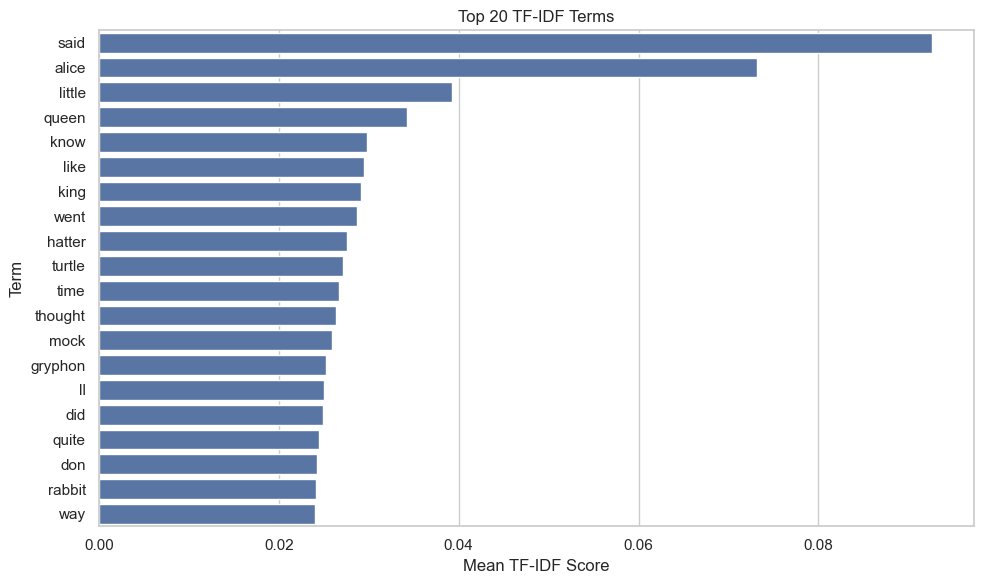

In [6]:
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_terms = np.array(tfidf.get_feature_names_out())

top_n = 20
top_idx = np.argsort(tfidf_means)[-top_n:][::-1]

top_terms_df = pd.DataFrame({
    "term": tfidf_terms[top_idx],
    "score": tfidf_means[top_idx]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms_df, x="score", y="term")
plt.title("Top 20 TF-IDF Terms")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

### 5.3 Sentence embeddings

In [7]:
text_model = SentenceTransformer("all-MiniLM-L6-v2")
X_embed = text_model.encode(text_df["clean_text"].tolist(), show_progress_bar=True)

print("Embedding shape:", X_embed.shape)

c:\Users\Greeny\anaconda3\envs\surface\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Greeny\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12874.01it/s]
BertModel LOAD REPOR

Embedding shape: (209, 384)


### 5.4 KMeans clustering comparison

In [8]:
n_clusters = 5

text_kmeans_tfidf = KMeans(n_clusters=n_clusters, random_state=42)
text_df["tfidf_cluster"] = text_kmeans_tfidf.fit_predict(X_tfidf)

text_kmeans_embed = KMeans(n_clusters=n_clusters, random_state=42)
text_df["embed_cluster"] = text_kmeans_embed.fit_predict(X_embed)

text_df[["clean_text", "tfidf_cluster", "embed_cluster"]].head()

,clean_text,tfidf_cluster,embed_cluster
0,down the rabbit hole alice was beginning to ge...,2,2
1,i shall be late when she thought it over after...,2,2
2,the rabbit hole went straight on like a tunnel...,2,2
3,she took down a jar from one of the shelves as...,2,2
4,let me see that would be four thousand miles d...,0,2


### 5.5 PCA visualisation: TF-IDF

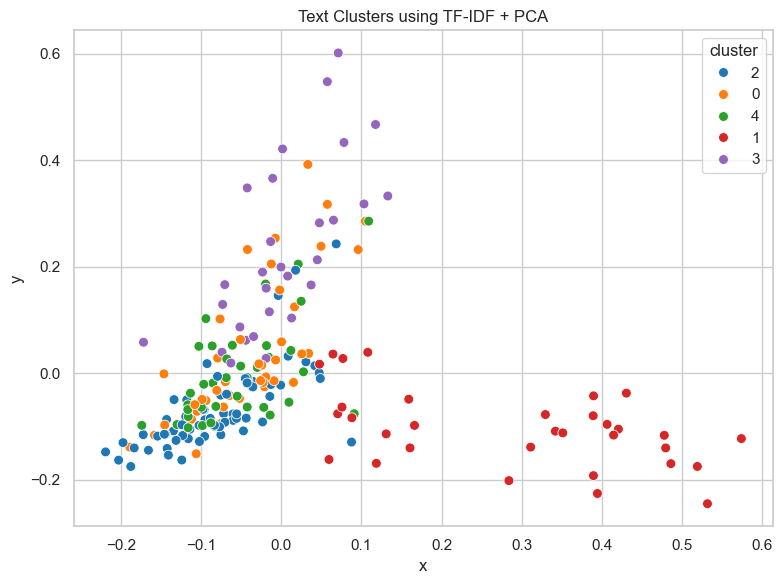

In [9]:
pca_tfidf = PCA(n_components=2)
X_tfidf_2d = pca_tfidf.fit_transform(X_tfidf.toarray())

tfidf_plot_df = pd.DataFrame({
    "x": X_tfidf_2d[:, 0],
    "y": X_tfidf_2d[:, 1],
    "cluster": text_df["tfidf_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tfidf_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Text Clusters using TF-IDF + PCA")
plt.tight_layout()
plt.show()

### 5.6 PCA visualisation: embeddings

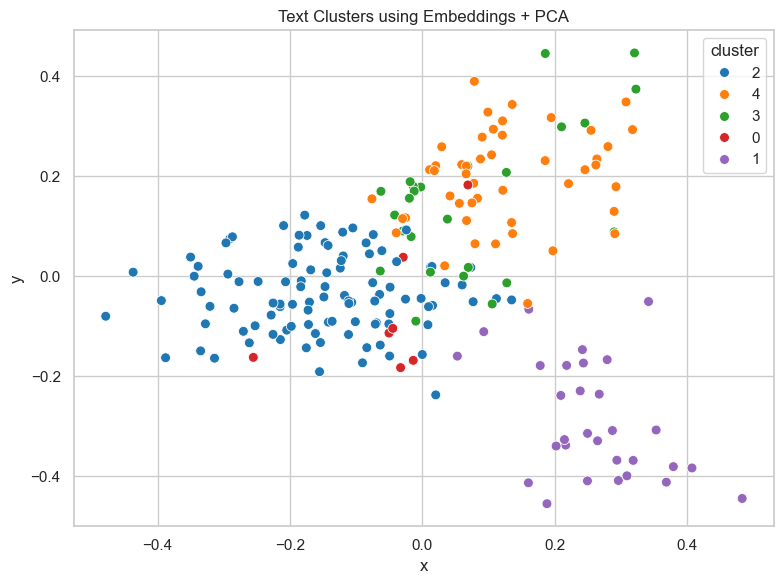

In [10]:
pca_embed = PCA(n_components=2)
X_embed_2d = pca_embed.fit_transform(X_embed)

embed_plot_df = pd.DataFrame({
    "x": X_embed_2d[:, 0],
    "y": X_embed_2d[:, 1],
    "cluster": text_df["embed_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=embed_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Text Clusters using Embeddings + PCA")
plt.tight_layout()
plt.show()

### 5.7 Cluster size comparison

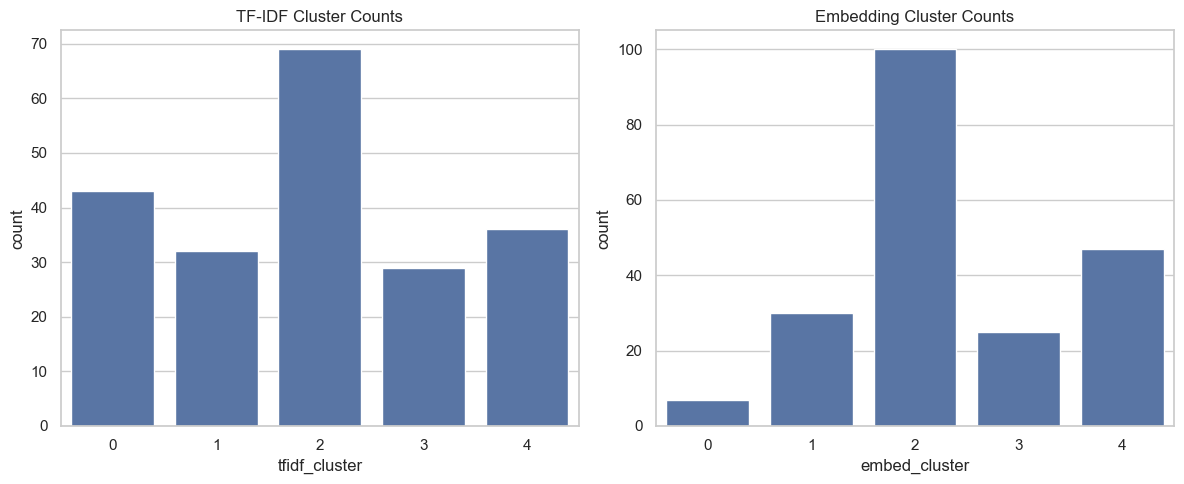

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=text_df, x="tfidf_cluster", ax=axes[0])
axes[0].set_title("TF-IDF Cluster Counts")

sns.countplot(data=text_df, x="embed_cluster", ax=axes[1])
axes[1].set_title("Embedding Cluster Counts")

plt.tight_layout()
plt.show()

### 5.8 Interim interpretation

TF-IDF is more interpretable because it reveals dominant keywords directly.  
Embeddings are expected to capture broader semantic similarity and may produce more coherent clusters.

The final judgement will be based on the visual cluster structure and later usefulness for design mapping.

## 6. Image Vectorisation

For the image dataset, the current comparison uses handcrafted visual features:
- brightness
- saturation
- edge density

These are especially useful because they can be directly mapped to geometric parameters later.

### 6.1 Inspect handcrafted image features

In [12]:
image_df[["brightness", "saturation", "edge_density"]].describe()

,brightness,saturation,edge_density
count,231.000000,231.000000,231.000000
mean,116.302603,101.514399,20.649082
std,43.045587,44.470964,14.925192
min,28.660992,0.000000,0.528202
25%,84.259619,71.074425,10.009575
50%,116.670284,93.870457,16.971531
75%,144.912216,132.719355,28.020487
max,246.073242,228.159084,83.827515


### 6.2 Plot brightness vs edge density

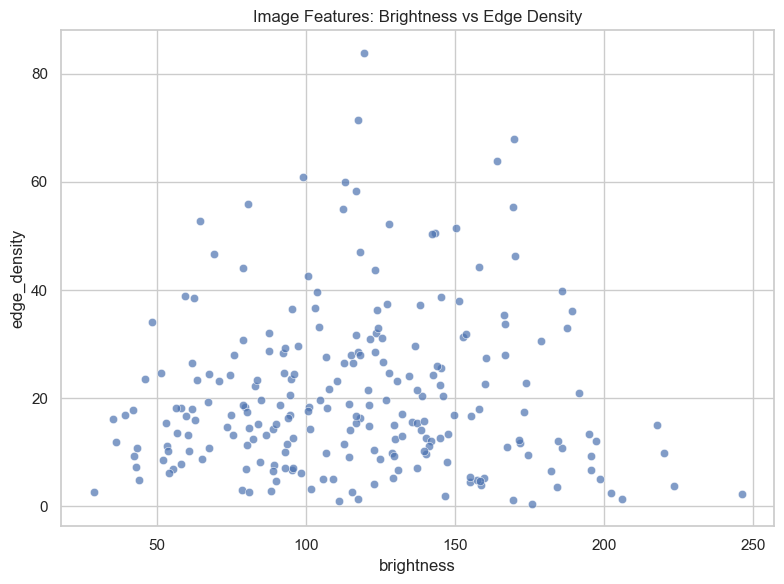

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=image_df, x="brightness", y="edge_density", alpha=0.7)
plt.title("Image Features: Brightness vs Edge Density")
plt.tight_layout()
plt.show()

### 6.3 Standardise image features

In [14]:
image_feature_cols = ["brightness", "saturation", "edge_density"]

image_scaler = StandardScaler()
X_image = image_scaler.fit_transform(image_df[image_feature_cols])

### 6.4 KMeans clustering on handcrafted image features

In [15]:
image_kmeans = KMeans(n_clusters=5, random_state=42)
image_df["image_cluster"] = image_kmeans.fit_predict(X_image)

image_df[["brightness", "saturation", "edge_density", "image_cluster"]].head()

,brightness,saturation,edge_density,image_cluster
0,152.730297,89.531120,31.253414,3
1,114.278633,105.534653,9.059200,0
2,149.746407,69.439190,16.839237,1
3,126.662529,79.775913,19.733162,0
4,80.581467,78.962467,55.836697,2


### 6.5 PCA visualisation for image clusters

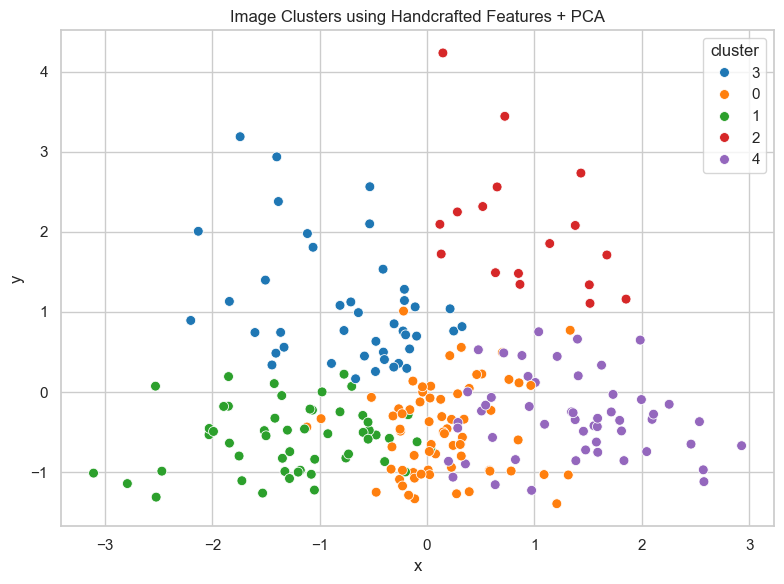

In [16]:
image_pca = PCA(n_components=2)
X_image_2d = image_pca.fit_transform(X_image)

image_plot_df = pd.DataFrame({
    "x": X_image_2d[:, 0],
    "y": X_image_2d[:, 1],
    "cluster": image_df["image_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=image_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Image Clusters using Handcrafted Features + PCA")
plt.tight_layout()
plt.show()

### 6.6 Cluster count plot

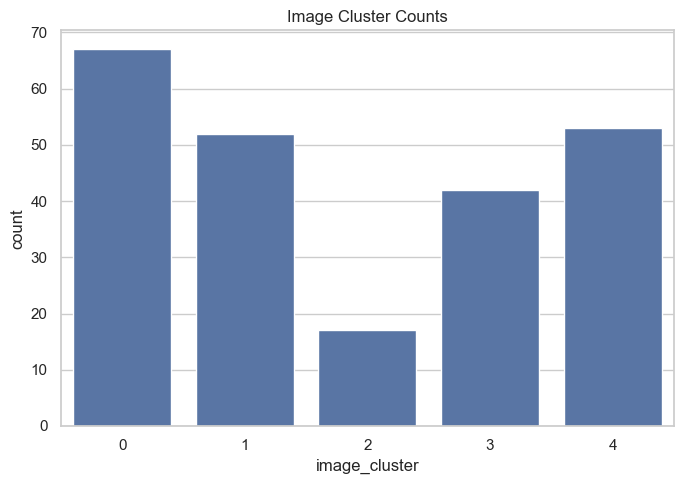

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=image_df, x="image_cluster")
plt.title("Image Cluster Counts")
plt.tight_layout()
plt.show()

### 6.7 Interim interpretation

Handcrafted image features are simple but effective for direct control tasks.
For example:
- brightness can later map to height or exposure-like spatial intensity
- saturation can later map to material intensity
- edge density can later map to complexity or fragmentation

## 7. Audio Vectorisation

The audio dataset is compared using:
- basic spectral features
- MFCC

Basic spectral features are more intuitive for direct animation and spatial control.  
MFCC provides a denser representation commonly used for machine listening and clustering.

### 7.1 Inspect existing audio features

In [18]:
audio_df[["duration_clean", "rms", "zcr", "spectral_centroid"]].describe()

,duration_clean,rms,zcr,spectral_centroid
count,350.000000,350.000000,350.000000,350.000000
mean,393.254838,0.037711,0.128326,2298.708129
std,816.071106,0.063235,0.116373,1275.280809
min,0.209206,0.000295,0.003258,173.895879
25%,30.372336,0.005098,0.051534,1435.565598
50%,76.559637,0.014851,0.088357,1974.981005
75%,254.230034,0.039157,0.164000,3003.746826
max,4812.443492,0.468115,0.606424,6597.733284


### 7.2 Plot basic audio features

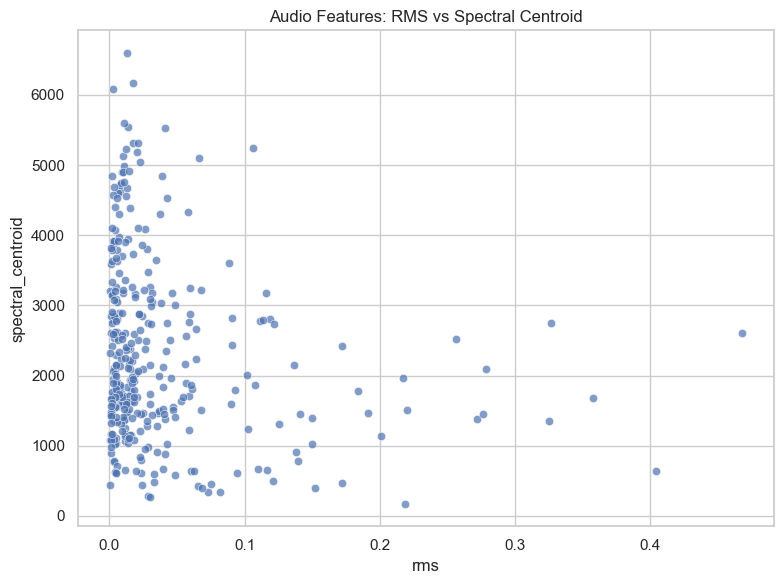

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=audio_df, x="rms", y="spectral_centroid", alpha=0.7)
plt.title("Audio Features: RMS vs Spectral Centroid")
plt.tight_layout()
plt.show()

### 7.3 KMeans clustering using basic spectral features

In [20]:
audio_feature_cols = ["duration_clean", "rms", "zcr", "spectral_centroid"]

audio_scaler = StandardScaler()
X_audio_basic = audio_scaler.fit_transform(audio_df[audio_feature_cols])

audio_kmeans_basic = KMeans(n_clusters=5, random_state=42)
audio_df["audio_basic_cluster"] = audio_kmeans_basic.fit_predict(X_audio_basic)

audio_df[audio_feature_cols + ["audio_basic_cluster"]].head()

,duration_clean,rms,zcr,spectral_centroid,audio_basic_cluster
0,9.771066,0.007996,0.212267,4631.344945,0
1,64.166168,0.075333,0.012516,457.364479,3
2,110.958549,0.065641,0.009511,430.598940,3
3,5.014059,0.056515,0.071999,1899.045851,3
4,3.959773,0.024671,0.060981,1473.670996,3


### 7.4 PCA visualisation for basic audio features

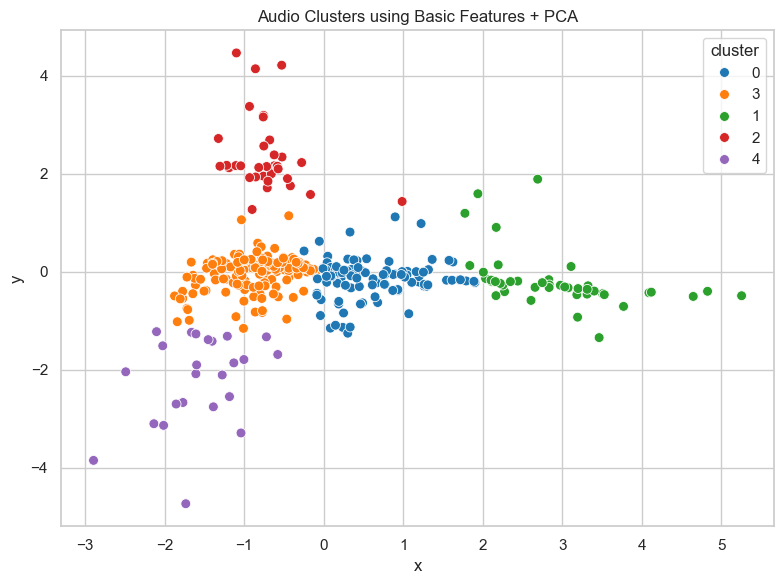

In [21]:
audio_pca_basic = PCA(n_components=2)
X_audio_basic_2d = audio_pca_basic.fit_transform(X_audio_basic)

audio_basic_plot_df = pd.DataFrame({
    "x": X_audio_basic_2d[:, 0],
    "y": X_audio_basic_2d[:, 1],
    "cluster": audio_df["audio_basic_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=audio_basic_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Audio Clusters using Basic Features + PCA")
plt.tight_layout()
plt.show()

### 7.5 Extract MFCC features

In [22]:
def extract_mfcc_mean(path, n_mfcc=13):
    try:
        y, sr = librosa.load(path, sr=22050, mono=True)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc.mean(axis=1)
    except Exception:
        return np.array([np.nan] * n_mfcc)

In [23]:
mfcc_features = audio_df["local_path"].apply(extract_mfcc_mean)

mfcc_df = pd.DataFrame(mfcc_features.tolist(), columns=[f"mfcc_{i+1}" for i in range(13)])
audio_df = pd.concat([audio_df.reset_index(drop=True), mfcc_df.reset_index(drop=True)], axis=1)

audio_df.head()

,id,source,freesound_id,name,username,license,duration,tags,description,audio_url,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,audio_0000,freesound,383184,chattering teeth - winding up,ChrisReierson,https://creativecommons.org/licenses/by/4.0/,9.77104,"chattering, effect, funny, humor, mechanical, ...",Winding up a miniature chattering teeth toy. I...,https://cdn.freesound.org/previews/383/383184_...,...,33.929169,35.070141,3.665223,12.676740,24.985468,-0.580403,11.944828,11.509631,9.856079,-0.135622
1,audio_0001,freesound,383169,wind gap indoors 002 170305_1100.wav,klankbeeld,https://creativecommons.org/licenses/by/4.0/,64.16610,"air-flow, air-stream, ajar, ambience, ambient,...",The wind ajar trough a door-gap indoors (10cm ...,https://cdn.freesound.org/previews/383/383169_...,...,32.069248,14.342833,9.970692,19.562788,7.211043,-1.689108,5.835673,6.298986,0.652640,2.040185
2,audio_0002,freesound,383139,wind gap indoors 001 170305_1100.wav,klankbeeld,https://creativecommons.org/licenses/by/4.0/,110.95900,"air-flow, air-stream, ajar, ambience, ambient,...",The wind ajar trough a door-gap indoors (10cm ...,https://cdn.freesound.org/previews/383/383139_...,...,32.581482,18.085220,17.279411,18.613485,11.435266,5.035427,5.928708,7.180472,4.874164,3.737484
3,audio_0003,freesound,379470,Wind3.mp3,vandale,http://creativecommons.org/publicdomain/zero/1.0/,5.01406,"air, breeze, gust, swoosh, wind",wind breeze swoosh air gust,https://cdn.freesound.org/previews/379/379470_...,...,-22.549938,-14.503655,18.949230,13.211223,9.521394,8.244902,15.977033,0.953145,22.368374,0.740013
4,audio_0004,freesound,379467,Wind2.ogg,vandale,http://creativecommons.org/publicdomain/zero/1.0/,3.95977,"air, breeze, gust, swoosh, wind",wind breeze swoosh air gust,https://cdn.freesound.org/previews/379/379467_...,...,-22.601332,-19.684685,14.946421,-11.926103,14.356014,7.941669,13.710144,-5.580842,21.002539,1.594467


### 7.6 KMeans clustering using MFCC

In [24]:
mfcc_cols = [f"mfcc_{i+1}" for i in range(13)]

audio_mfcc_valid = audio_df.dropna(subset=mfcc_cols).copy()

audio_scaler_mfcc = StandardScaler()
X_audio_mfcc = audio_scaler_mfcc.fit_transform(audio_mfcc_valid[mfcc_cols])

audio_kmeans_mfcc = KMeans(n_clusters=5, random_state=42)
audio_mfcc_valid["audio_mfcc_cluster"] = audio_kmeans_mfcc.fit_predict(X_audio_mfcc)

audio_mfcc_valid[mfcc_cols + ["audio_mfcc_cluster"]].head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,audio_mfcc_cluster
0,-500.308411,2.047567,35.219711,33.929169,35.070141,3.665223,12.676740,24.985468,-0.580403,11.944828,11.509631,9.856079,-0.135622,1
1,-368.298798,164.781754,52.611958,32.069248,14.342833,9.970692,19.562788,7.211043,-1.689108,5.835673,6.298986,0.652640,2.040185,2
2,-394.160675,137.422470,68.251724,32.581482,18.085220,17.279411,18.613485,11.435266,5.035427,5.928708,7.180472,4.874164,3.737484,1
3,-333.248688,117.955711,32.067474,-22.549938,-14.503655,18.949230,13.211223,9.521394,8.244902,15.977033,0.953145,22.368374,0.740013,1
4,-359.624115,142.651596,25.984875,-22.601332,-19.684685,14.946421,-11.926103,14.356014,7.941669,13.710144,-5.580842,21.002539,1.594467,2


### 7.7 PCA visualisation for MFCC

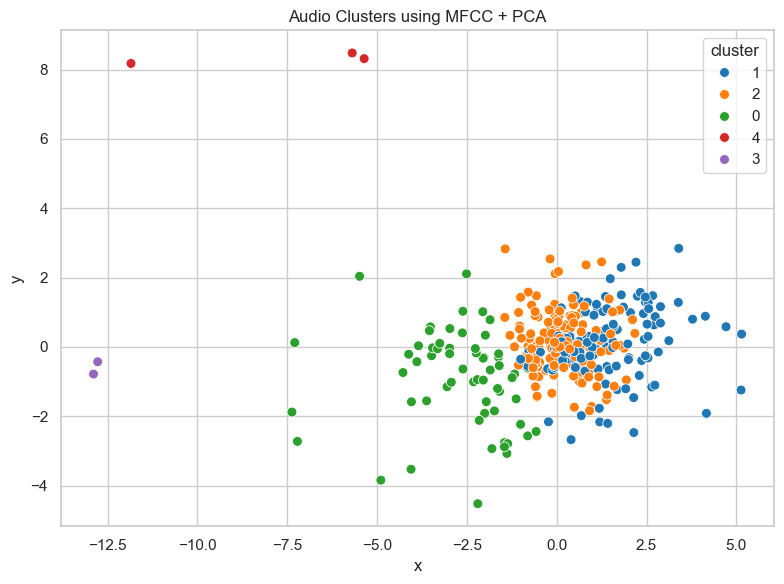

In [25]:
audio_pca_mfcc = PCA(n_components=2)
X_audio_mfcc_2d = audio_pca_mfcc.fit_transform(X_audio_mfcc)

audio_mfcc_plot_df = pd.DataFrame({
    "x": X_audio_mfcc_2d[:, 0],
    "y": X_audio_mfcc_2d[:, 1],
    "cluster": audio_mfcc_valid["audio_mfcc_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=audio_mfcc_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Audio Clusters using MFCC + PCA")
plt.tight_layout()
plt.show()

### 7.8 Compare cluster counts

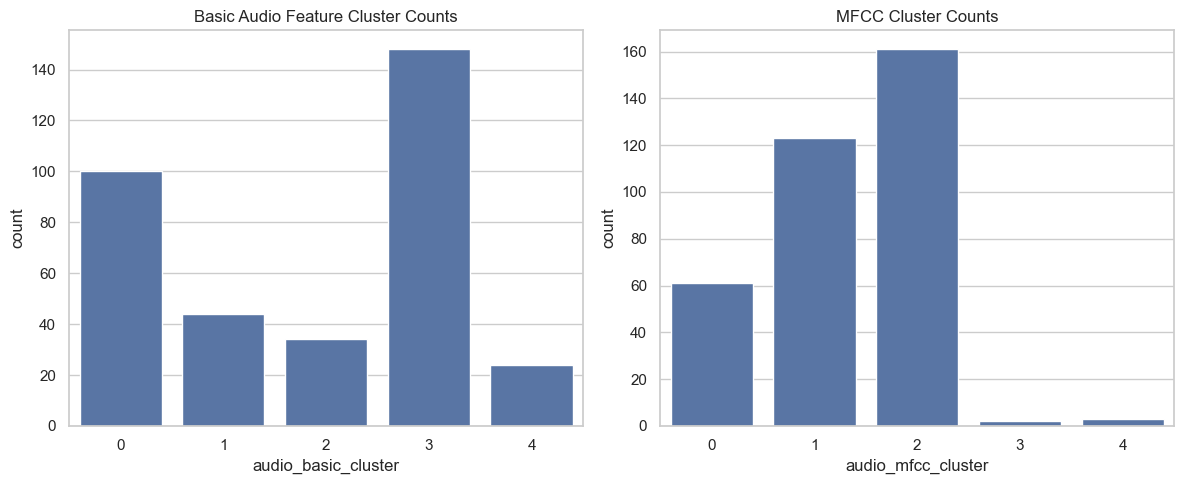

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=audio_df, x="audio_basic_cluster", ax=axes[0])
axes[0].set_title("Basic Audio Feature Cluster Counts")

sns.countplot(data=audio_mfcc_valid, x="audio_mfcc_cluster", ax=axes[1])
axes[1].set_title("MFCC Cluster Counts")

plt.tight_layout()
plt.show()

### 7.9 Interim interpretation

Basic spectral features are more intuitive and easier to map directly to animation parameters.  
MFCC provides a denser representation and may capture more nuanced sonic similarity.

The comparison is useful because one method may be better for direct control, while the other may be better for clustering quality.

## 8. Save Processed Outputs

The vectorisation outputs and cluster labels are saved for later use in parameter mapping and design integration.

In [27]:
text_df.to_csv(PROCESSED_DIR / "text_vectorised.csv", index=False, encoding="utf-8-sig")
image_df.to_csv(PROCESSED_DIR / "image_vectorised.csv", index=False, encoding="utf-8-sig")
audio_df.to_csv(PROCESSED_DIR / "audio_basic_vectorised.csv", index=False, encoding="utf-8-sig")
audio_mfcc_valid.to_csv(PROCESSED_DIR / "audio_mfcc_vectorised.csv", index=False, encoding="utf-8-sig")

print("Saved processed files to:", PROCESSED_DIR)

Saved processed files to: D:\Work\Workspace\Projects\Python\data-driven-surface\data\processed


## 9. Comparison Summary

### Text
- TF-IDF provides interpretable word-level signals
- embeddings provide broader semantic grouping

### Image
- handcrafted features are direct and controllable for later geometry mapping

### Audio
- basic spectral features are intuitive for animation control
- MFCC may provide richer clustering structure

These outputs will inform the next notebook, which will focus on structured parameter mapping for 3D generation.

## Next Step

The next notebook will focus on:
- structured parameter generation
- OpenAI API tagging for text
- mapping vectorised outputs to design variables
- preparing a parameter table for Blender / TouchDesigner / other 3D tools